<a href="https://colab.research.google.com/github/adriangonz-afk/Soccer-Performance-Prediction-ML./blob/main/PROYECTO_CEBOLLITAS_ML_GITHUB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Proyecto de Análisis Predictivo y Segmentación: Cebollitas FC**

## Introducción y Carga de Datos
El presente proyecto desarrolla un flujo de trabajo de ciencia de datos aplicado al rendimiento deportivo del equipo Cebollitas FC. El objetivo es utilizar métricas recolectadas en campo para predecir resultados y segmentar perfiles de rendimiento.  
El conjunto de datos inicial consta de 100 registros con variables críticas como posesión de balón, tiros al arco y goles marcados.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
path= "/data/partidos_cebollitas.csv"
df = pd.read_csv(path)
df.head()

,fecha_partido,equipo_local,equipo_visitante,goles_local,goles_visitante,posesion_local (%),posesion_visitante (%),tiros_arco_local,tiros_arco_visitante,estadio
0,2023-01-01,Atlético Python,Cebollitas FC,2,0,54,46,12,6,Python Arena
1,2023-01-08,NumPy City,Atlético Python,1,5,60,40,12,3,Estadio ML
2,2023-01-15,Cebollitas FC,Data United,1,0,55,45,10,7,Python Arena
3,2023-01-22,Atlético Python,Data United,2,3,57,43,3,3,Campo Pandas
4,2023-01-29,Data United,Cebollitas FC,5,3,52,48,7,12,Estadio ML


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   fecha_partido           100 non-null    object
 1   equipo_local            100 non-null    object
 2   equipo_visitante        100 non-null    object
 3   goles_local             100 non-null    int64 
 4   goles_visitante         100 non-null    int64 
 5   posesion_local (%)      100 non-null    int64 
 6   posesion_visitante (%)  100 non-null    int64 
 7   tiros_arco_local        100 non-null    int64 
 8   tiros_arco_visitante    100 non-null    int64 
 9   estadio                 100 non-null    object
dtypes: int64(6), object(4)
memory usage: 7.9+ KB


## Análisis Exploratorio y Limpieza de Datos
Se realizó una auditoría de calidad sobre los datos para asegurar la integridad de las conclusiones:

- Se verificó la ausencia de valores nulos en las columnas principales para evitar sesgos en el entrenamiento de los modelos.
- El análisis descriptivo muestra que el equipo local anota en promedio 2.63 goles, mientras que el visitante promedia 2.54.
- Las visualizaciones mediante histogramas revelan que las distribuciones de goles presentan variaciones que sugieren comportamientos no lineales en el rendimiento de los equipos.
- Se utilizaron diagramas de caja para identificar la dispersión de los goles y validar la consistencia de los datos recolectados.


In [ ]:
print(df.isnull().sum())


fecha_partido             0
equipo_local              0
equipo_visitante          0
goles_local               0
goles_visitante           0
posesion_local (%)        0
posesion_visitante (%)    0
tiros_arco_local          0
tiros_arco_visitante      0
estadio                   0
dtype: int64


In [ ]:
df.isnull().sum()
df['goles_local'].fillna(df['goles_local'].mean(), inplace=True)
print('Valores nulos antes de la inputacion')
print(df.isnull().sum())

Valores nulos antes de la inputacion
fecha_partido             0
equipo_local              0
equipo_visitante          0
goles_local               0
goles_visitante           0
posesion_local (%)        0
posesion_visitante (%)    0
tiros_arco_local          0
tiros_arco_visitante      0
estadio                   0
dtype: int64


/tmp/ipython-input-3347864388.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['goles_local'].fillna(df['goles_local'].mean(), inplace=True)


In [ ]:
df_listo = pd.get_dummies(df, columns=['equipo_local', 'equipo_visitante'])
df_listo.head()

,fecha_partido,goles_local,goles_visitante,posesion_local (%),posesion_visitante (%),tiros_arco_local,tiros_arco_visitante,estadio,equipo_local_Atlético Python,equipo_local_Cebollitas FC,equipo_local_Data United,equipo_local_NumPy City,equipo_local_Real Pandas,equipo_visitante_Atlético Python,equipo_visitante_Cebollitas FC,equipo_visitante_Data United,equipo_visitante_NumPy City,equipo_visitante_Real Pandas
0,2023-01-01,2,0,54,46,12,6,Python Arena,True,False,False,False,False,False,True,False,False,False
1,2023-01-08,1,5,60,40,12,3,Estadio ML,False,False,False,True,False,True,False,False,False,False
2,2023-01-15,1,0,55,45,10,7,Python Arena,False,True,False,False,False,False,False,True,False,False
3,2023-01-22,2,3,57,43,3,3,Campo Pandas,True,False,False,False,False,False,False,True,False,False
4,2023-01-29,5,3,52,48,7,12,Estadio ML,False,False,True,False,False,False,True,False,False,False


In [ ]:
df_listo.drop_duplicates(inplace=True)

In [ ]:
df_listo["fecha_partido"] = pd.to_datetime(df_listo["fecha_partido"], errors='coerce')
df_listo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   fecha_partido                     100 non-null    datetime64[ns]
 1   goles_local                       100 non-null    int64         
 2   goles_visitante                   100 non-null    int64         
 3   posesion_local (%)                100 non-null    int64         
 4   posesion_visitante (%)            100 non-null    int64         
 5   tiros_arco_local                  100 non-null    int64         
 6   tiros_arco_visitante              100 non-null    int64         
 7   estadio                           100 non-null    object        
 8   equipo_local_Atlético Python      100 non-null    bool          
 9   equipo_local_Cebollitas FC        100 non-null    bool          
 10  equipo_local_Data United          100 non-null    b

In [ ]:
df_listo.shape

(100, 18)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df_listo.describe()


,fecha_partido,goles_local,goles_visitante,posesion_local (%),posesion_visitante (%),tiros_arco_local,tiros_arco_visitante
count,100,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2023-12-13 12:00:00,2.63000,2.540000,50.250000,49.750000,7.580000,7.870000
min,2023-01-01 00:00:00,0.00000,0.000000,40.000000,40.000000,3.000000,3.000000
25%,2023-06-23 06:00:00,1.00000,1.000000,45.000000,44.750000,5.000000,5.000000
50%,2023-12-13 12:00:00,3.00000,3.000000,51.000000,49.000000,7.500000,8.000000
75%,2024-06-03 18:00:00,4.00000,4.000000,55.250000,55.000000,10.000000,11.000000
max,2024-11-24 00:00:00,5.00000,5.000000,60.000000,60.000000,12.000000,12.000000
std,NaN,1.58691,1.788967,6.035878,6.035878,2.899599,2.966667


## Preprocesamiento y Feature Engineering
Para mejorar la capacidad predictiva, se transformaron los datos crudos en variables con mayor significado estadístico:

- Se implementó la técnica de **variables indicadoras** para manejar los nombres de los equipos y estadios de forma numérica.
- Se aplicó **escalado (Min-Max)** a los tiros al arco y **estandarización** a los porcentajes de posesión.
- Se crearon nuevas métricas como la **diferencia de goles** y el **ratio de tiros por porcentaje de posesión** para capturar la eficiencia ofensiva.


In [ ]:

# Promedio goles Cebollitas como local y visitante
goles_local_cebo = df[df['equipo_local'] == 'Cebollitas FC']['goles_local'].mean()
goles_visitante_cebo = df[df['equipo_visitante'] == 'Cebollitas FC']['goles_visitante'].mean()

print("Goles promedio Cebollitas FC como local:", goles_local_cebo)
print("Goles promedio Cebollitas FC como visitante:", goles_visitante_cebo)

Goles promedio Cebollitas FC como local: 2.230769230769231
Goles promedio Cebollitas FC como visitante: 2.611111111111111


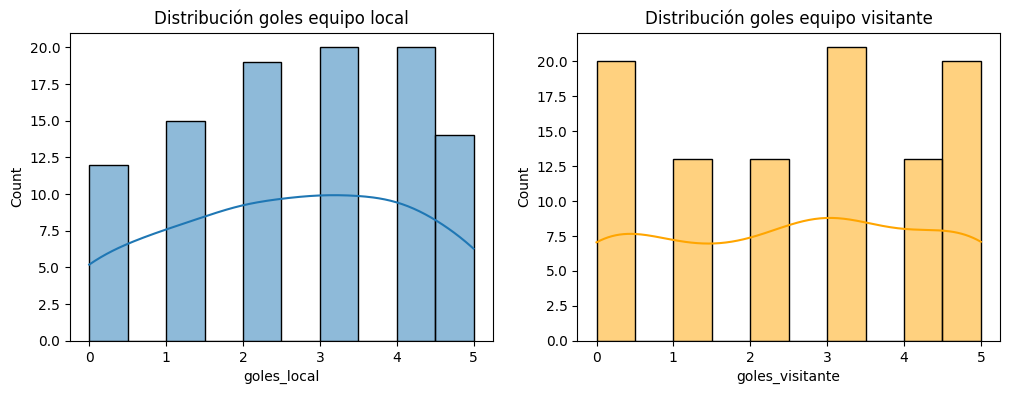

In [ ]:
# Histogramas de goles marcados (local y visitante)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['goles_local'], kde=True, ax=ax[0], bins=10)
ax[0].set_title('Distribución goles equipo local')

sns.histplot(df['goles_visitante'], kde=True, ax=ax[1], bins=10, color='orange')
ax[1].set_title('Distribución goles equipo visitante')

plt.show()

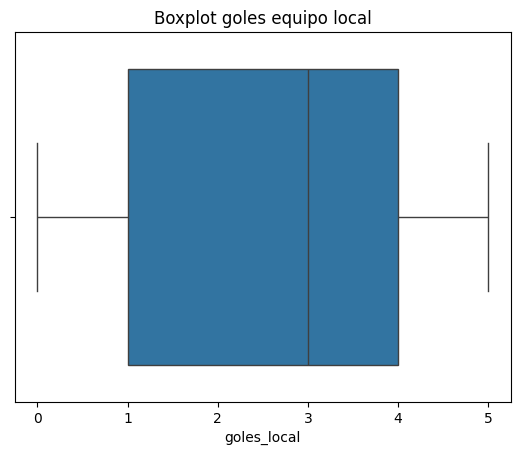

In [ ]:
# Boxplot para goles del equipo local
sns.boxplot(x=df['goles_local'])
plt.title('Boxplot goles equipo local')
plt.show()

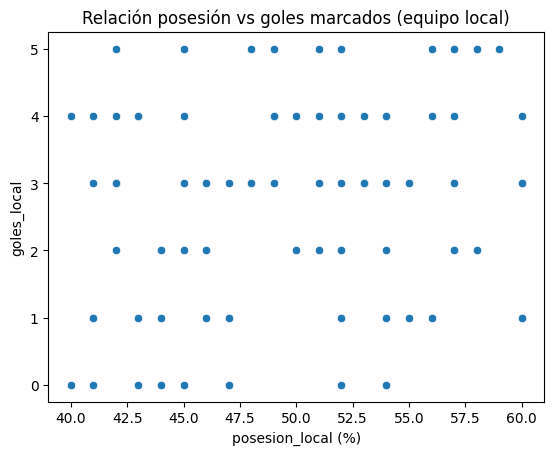

In [ ]:
# Scatterplot de posesión vs goles marcados (local)
sns.scatterplot(x='posesion_local (%)', y='goles_local', data=df)
plt.title('Relación posesión vs goles marcados (equipo local)')
plt.show()

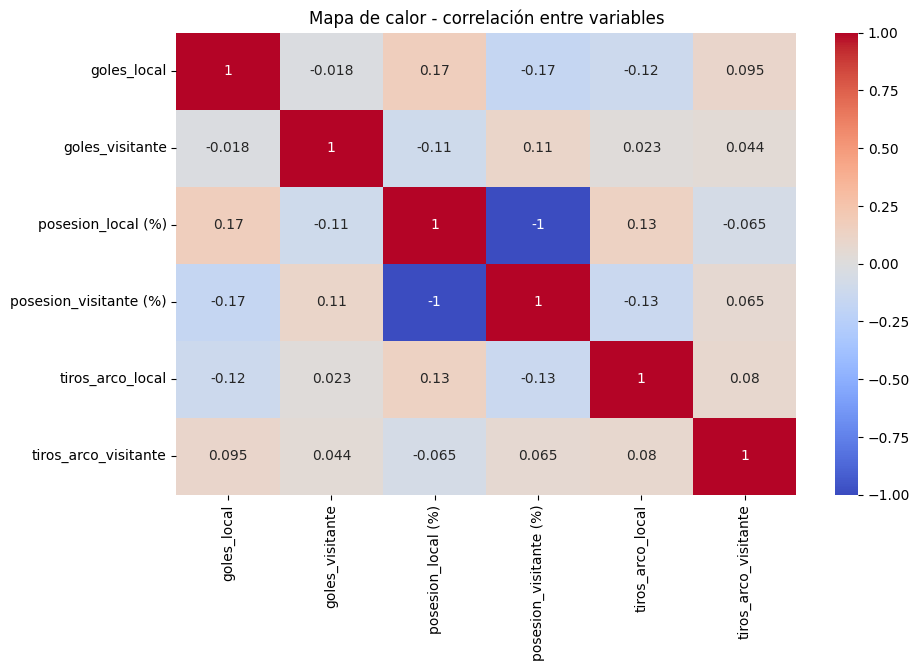

In [ ]:
# Mapa de calor para correlación entre variables clave
plt.figure(figsize=(10,6))
sns.heatmap(df[['goles_local', 'goles_visitante', 'posesion_local (%)',
                         'posesion_visitante (%)', 'tiros_arco_local',
                         'tiros_arco_visitante']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Mapa de calor - correlación entre variables')
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Cargar dataset preparado previamente
df_partidos = pd.read_csv("/data/partidos_cebollitas.csv")
df_partidos.head()

,fecha_partido,equipo_local,equipo_visitante,goles_local,goles_visitante,posesion_local (%),posesion_visitante (%),tiros_arco_local,tiros_arco_visitante,estadio
0,2023-01-01,Atlético Python,Cebollitas FC,2,0,54,46,12,6,Python Arena
1,2023-01-08,NumPy City,Atlético Python,1,5,60,40,12,3,Estadio ML
2,2023-01-15,Cebollitas FC,Data United,1,0,55,45,10,7,Python Arena
3,2023-01-22,Atlético Python,Data United,2,3,57,43,3,3,Campo Pandas
4,2023-01-29,Data United,Cebollitas FC,5,3,52,48,7,12,Estadio ML


Normalización y Escalado: El uso de MinMaxScaler y StandardScaler responde a la necesidad de equilibrar variables con rangos dispares, como la posesión y los tiros al arco, optimizando la convergencia de los algoritmos basados en gradiente y distancias euclidianas.

In [ ]:

# Aplicar Normalización a tiros al arco (aprox. 0-15 tiros)
scaler_norm = MinMaxScaler()

df_partidos['tiros_arco_local_norm'] = scaler_norm.fit_transform(df_partidos[['tiros_arco_local']])
df_partidos['tiros_arco_visitante_norm'] = scaler_norm.fit_transform(df_partidos[['tiros_arco_visitante']])

# Ver resultados
print(df_partidos[['tiros_arco_local','tiros_arco_local_norm']].head(6))
print(df_partidos[['tiros_arco_visitante','tiros_arco_visitante_norm']].head(6))

   tiros_arco_local  tiros_arco_local_norm
0                12               1.000000
1                12               1.000000
2                10               0.777778
3                 3               0.000000
4                 7               0.444444
5                 8               0.555556
   tiros_arco_visitante  tiros_arco_visitante_norm
0                     6                   0.333333
1                     3                   0.000000
2                     7                   0.444444
3                     3                   0.000000
4                    12                   1.000000
5                    11                   0.888889


In [ ]:
# Aplicar Estandarización a la posesión (%)
scaler_std = StandardScaler()

df_partidos['posesion_local_std'] = scaler_std.fit_transform(df_partidos[['posesion_local (%)']])
df_partidos['posesion_visitante_std'] = scaler_std.fit_transform(df_partidos[['posesion_visitante (%)']])

# Ver resultados
df_partidos[['posesion_local (%)','posesion_local_std']].head()

,posesion_local (%),posesion_local_std
0,54,0.624415
1,60,1.623479
2,55,0.790926
3,57,1.123947
4,52,0.291394


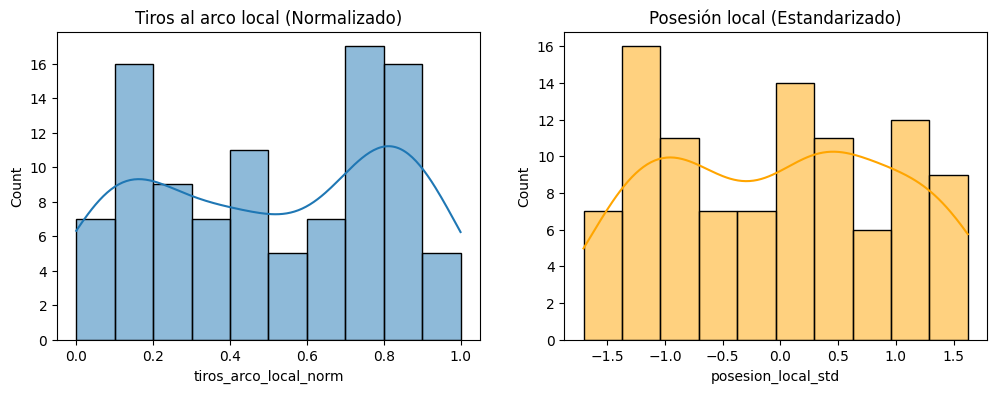

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12,4))

# Visualizar tiros al arco (Normalización)
sns.histplot(df_partidos['tiros_arco_local_norm'], kde=True, bins=10, ax=ax[0])

ax[0].set_title("Tiros al arco local (Normalizado)")

# Visualizar posesión local (Estandarización)
sns.histplot(df_partidos['posesion_local_std'], bins=10,kde=True, ax=ax[1], color='orange')
ax[1].set_title("Posesión local (Estandarizado)")

plt.show()

## Ingeniería de Características y Selección

La creación de nuevas variables permitió capturar dinámicas del juego que no estaban presentes de forma explícita en el dataset original.

### Feature Engineering
- Se desarrollaron métricas de eficiencia, como la diferencia de goles y el ratio de tiros por posesión, que resultaron ser predictores más robustos que las variables aisladas.

### Selección de Variables
- Mediante SelectKBest con la función f_regression, se identificó que la posesión de balón tiene la mayor relevancia estadística para predecir el resultado, seguida de cerca por el ratio de tiros.


In [ ]:
# Nueva característica: diferencia de goles (local - visitante)
df_partidos['diferencia_goles'] = df_partidos['goles_local'] - df_partidos['goles_visitante']

# Ver resultados
df_partidos[['goles_local', 'goles_visitante', 'diferencia_goles']].head()

,goles_local,goles_visitante,diferencia_goles
0,2,0,2
1,1,5,-4
2,1,0,1
3,2,3,-1
4,5,3,2


In [ ]:
# Nueva característica: ratio tiros al arco por porcentaje de posesión (local)
df_partidos['ratio_tiros_posesion_local'] = df_partidos['tiros_arco_local'] / df_partidos['posesion_local (%)']

# Ver resultados
df_partidos[['tiros_arco_local', 'posesion_local (%)', 'ratio_tiros_posesion_local']].head()

,tiros_arco_local,posesion_local (%),ratio_tiros_posesion_local
0,12,54,0.222222
1,12,60,0.200000
2,10,55,0.181818
3,3,57,0.052632
4,7,52,0.134615


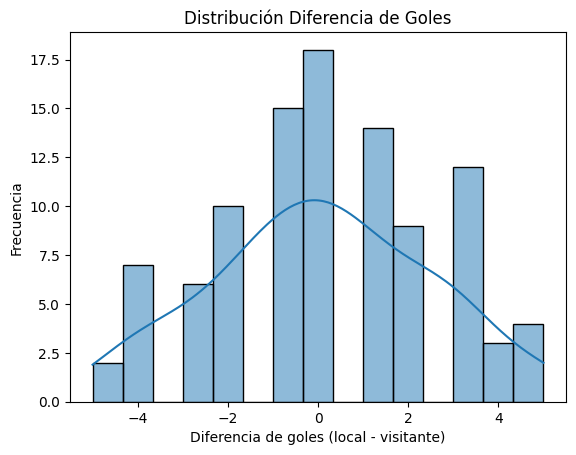

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de diferencia de goles
sns.histplot(df_partidos['diferencia_goles'], bins=15, kde=True)
plt.title('Distribución Diferencia de Goles')
plt.xlabel('Diferencia de goles (local - visitante)')
plt.ylabel('Frecuencia')
plt.show()

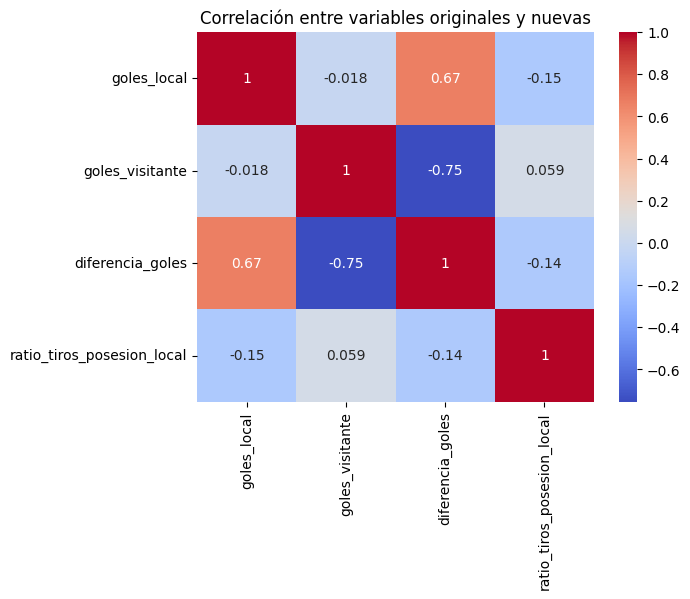

In [ ]:
# Análisis de correlaciones
corr_vars = ['goles_local', 'goles_visitante', 'diferencia_goles', 'ratio_tiros_posesion_local']
corr_matrix = df_partidos[corr_vars].corr()

# Mapa de calor
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlación entre variables originales y nuevas')
plt.show()

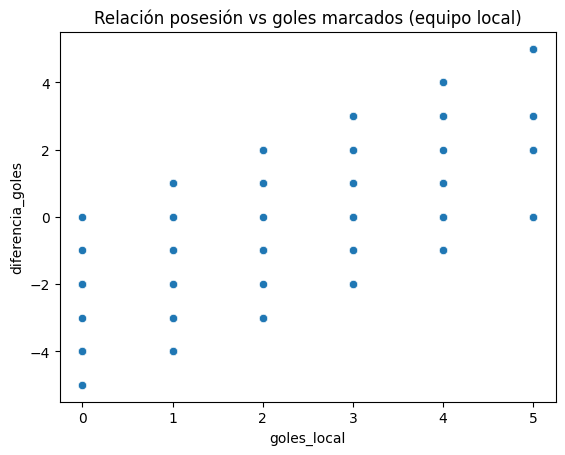

In [ ]:
sns.scatterplot(y='diferencia_goles', x='goles_local', data=df_partidos)
plt.title('Relación posesión vs goles marcados (equipo local)')
plt.show()

## Modelado Supervisado: Predicción de Resultados
El proyecto evaluó diferentes algoritmos para predecir la diferencia de goles en un partido:

### Evaluación de Modelos de Regresión

- **Regresión Lineal**:  
  Se determinó que este modelo es insuficiente para el contexto deportivo, obteniendo un coeficiente de determinación ($R^2$) de -0.03, lo que indica que la varianza del resultado no puede ser explicada por una función lineal simple.

- **Random Forest Regressor**:  
  Al emplear un algoritmo de ensamble basado en 1,000 árboles de decisión, se logró capturar las interacciones no lineales entre las variables, elevando el $R^2$ a 0.83 y reduciendo el error absoluto medio (MAE) a 0.67 y asu demostrando una alta fidelidad en las predicciones.



In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

# Variables predictoras y objetivo
X = df_partidos[['posesion_local (%)', 'tiros_arco_local', 'ratio_tiros_posesion_local']]
y = df_partidos['goles_local']

# Seleccionar las 2 mejores variables
selector = SelectKBest(score_func = f_regression, k=2)#Mide la correlacion lineal
selector.fit(X, y)#Calcula la media y varianza

# Resultados ordenados por relevancia
scores = selector.scores_
variables = X.columns

resultados = pd.DataFrame({'Variable': variables, 'Score': scores}).sort_values(by='Score', ascending=False)
resultados

,Variable,Score
0,posesion_local (%),2.844159
2,ratio_tiros_posesion_local,2.323320
1,tiros_arco_local,1.372691


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Entrenar árbol de decisión para medir la importancia
modelo_arbol = DecisionTreeRegressor(random_state=42)
modelo_arbol.fit(X, y)

# Importancia calculada por el modelo
importancia = modelo_arbol.feature_importances_

resultado_importancia = pd.DataFrame({
    'Variable': variables,
    'Importancia': importancia
}).sort_values(by='Importancia', ascending=False)

resultado_importancia

,Variable,Importancia
0,posesion_local (%),0.491563
2,ratio_tiros_posesion_local,0.305755
1,tiros_arco_local,0.202683


/tmp/ipython-input-1859837649.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Variable', data=resultados, ax=ax[0], palette='Blues_r')
/tmp/ipython-input-1859837649.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=resultado_importancia, ax=ax[1], palette='Greens_r')


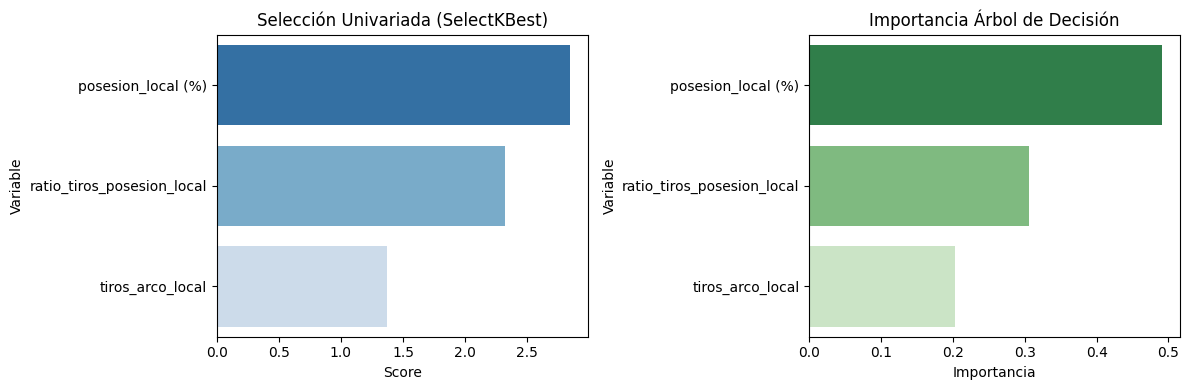

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12,4))

# Gráfica SelectKBest (análisis univariado)
sns.barplot(x='Score', y='Variable', data=resultados, ax=ax[0], palette='Blues_r')
ax[0].set_title('Selección Univariada (SelectKBest)')

# Gráfica Importancia (árbol decisión)
sns.barplot(x='Importancia', y='Variable', data=resultado_importancia, ax=ax[1], palette='Greens_r')
ax[1].set_title('Importancia Árbol de Decisión')

plt.tight_layout()
plt.show()

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
import ipywidgets as widgets
from IPython.display import display

# Slider interactivo para elegir porcentaje de prueba
slider_test_size = widgets.FloatSlider(
    value=0.2, min=0.1, max=0.5, step=0.05,
    description='% Test Set:', continuous_update=False
)

display(slider_test_size)

FloatSlider(value=0.2, continuous_update=False, description='% Test Set:', max=0.5, min=0.1, step=0.05)

In [ ]:
def dividir_datos(test_size):
    X = df_partidos[['posesion_local (%)', 'tiros_arco_local', 'goles_local']]
    y = df_partidos['diferencia_goles']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    print(f"Tamaño conjunto entrenamiento: {len(X_train)} partidos")
    print(f"Tamaño conjunto prueba: {len(X_test)} partidos")

    return X_train, X_test, y_train, y_test

# Usa el widget interactivo
widgets.interactive(dividir_datos, test_size=slider_test_size)

interactive(children=(FloatSlider(value=0.2, continuous_update=False, description='% Test Set:', max=0.5, min=…

In [ ]:
# División estándar recomendada (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    df_partidos[['posesion_local (%)', 'tiros_arco_local', 'goles_local']],
    df_partidos['diferencia_goles'],
    test_size=0.2, random_state=42
)

print("Conjunto de entrenamiento (primeros registros):")
display(X_train.head())

print("\nConjunto de prueba (primeros registros):")
display(X_test.head())

Conjunto de entrenamiento (primeros registros):


,posesion_local (%),tiros_arco_local,goles_local
55,51,6,4
88,54,9,0
26,53,4,3
42,52,4,2
69,60,9,1



Conjunto de prueba (primeros registros):


,posesion_local (%),tiros_arco_local,goles_local
83,47,3,3
53,60,3,4
70,50,5,2
45,57,7,5
44,45,5,5


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Cargar dataset
df_partidos = pd.read_csv("/data/partidos_cebollitas.csv")

# Crear variable objetivo
df_partidos['diferencia_goles'] = df_partidos['goles_local'] - df_partidos['goles_visitante']

# Variables predictoras
X = df_partidos[['posesion_local (%)', 'tiros_arco_local']]
y = df_partidos['diferencia_goles']

# División estándar: 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

from sklearn.linear_model import LinearRegression

# Instanciar y entrenar modelo
modelo_rl = LinearRegression()
modelo_rl.fit(X_train, y_train)

print("¡Modelo entrenado exitosamente!")

¡Modelo entrenado exitosamente!


In [ ]:

# Mostrar coeficientes
print(f"Intercepto (β₀): {modelo_rl.intercept_}")
print(f"Coeficientes (β): {modelo_rl.coef_}")

# Interpretación amigable
for idx, col_name in enumerate(X.columns):
    print(f"Si aumentamos 1 unidad en '{col_name}', la diferencia de goles cambia en promedio {modelo_rl.coef_[idx]:.2f}")

Intercepto (β₀): -2.5257192572329763
Coeficientes (β): [ 0.05596278 -0.05125811]
Si aumentamos 1 unidad en 'posesion_local (%)', la diferencia de goles cambia en promedio 0.06
Si aumentamos 1 unidad en 'tiros_arco_local', la diferencia de goles cambia en promedio -0.05


In [ ]:
# Hacer predicciones
y_pred = modelo_rl.predict(X_test)
import math
# Comparar predicciones vs valores reales
df_resultados = X_test.copy()
df_resultados['Diferencia_Goles_Real'] = y_test
df_resultados['Diferencia_Goles_Predicha'] = y_pred.round(2)
df_resultados.head(10)


,posesion_local (%),tiros_arco_local,Diferencia_Goles_Real,Diferencia_Goles_Predicha
83,47,3,3,-0.05
53,60,3,3,0.68
70,50,5,0,0.02
45,57,7,3,0.31
44,45,5,5,-0.26
39,60,7,3,0.47
22,45,11,0,-0.57
80,49,5,1,-0.04
10,48,5,-2,-0.10
0,54,12,2,-0.12


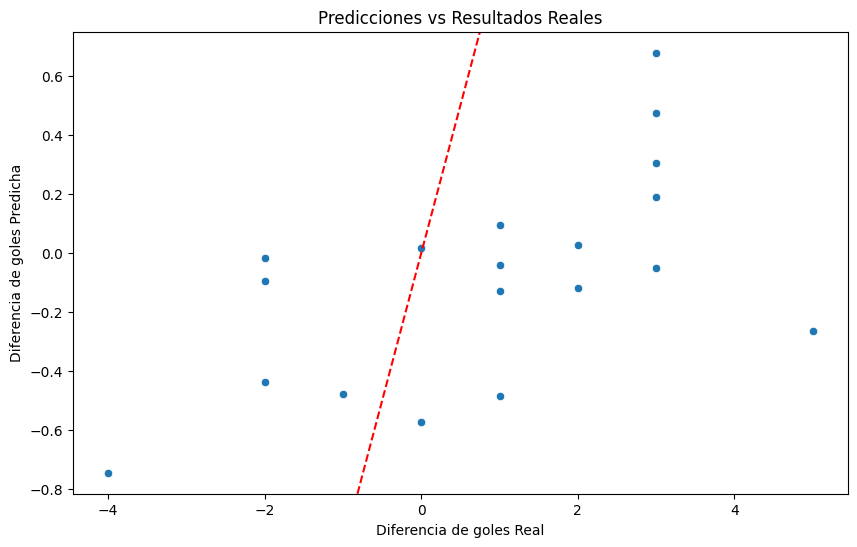

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Crear gráfico de dispersión
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Diferencia de goles Real')
plt.ylabel('Diferencia de goles Predicha')
plt.title('Predicciones vs Resultados Reales')
plt.axline((0,0), slope=1, color='red', linestyle='--')  # Línea ideal
plt.show()

In [ ]:

import ipywidgets as widgets

# Widgets de entrada
posesion_input = widgets.FloatSlider(min=df_partidos['posesion_local (%)'].min(), max=df_partidos['posesion_local (%)'].max(), step=1, description='Posesión (%)')
tiros_input = widgets.IntSlider(min=df_partidos['tiros_arco_local'].min(), max=df_partidos['tiros_arco_local'].max(), step=1, description='Tiros al Arco')

# Función de predicción
def predecir_goles(posesion, tiros):
    # Crear DataFrame con nombres de columnas esperados por el modelo
    entrada = pd.DataFrame([[posesion, tiros]], columns=['posesion_local (%)', 'tiros_arco_local'])
    pred = modelo_rl.predict(entrada)[0]
    print(f"Diferencia de goles predicha: {pred:.2f}")


# Mostrar widget interactivo
widgets.interactive(predecir_goles, posesion=posesion_input, tiros=tiros_input)

interactive(children=(FloatSlider(value=40.0, description='Posesión (%)', max=60.0, min=40.0, step=1.0), IntSl…

In [ ]:
modelo_rl.score(X,y)

0.03707509052525604

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df_partidos = pd.read_csv("/data/partidos_cebollitas.csv")
df_partidos['diferencia_goles'] = df_partidos['goles_local'] - df_partidos['goles_visitante']

X = df_partidos[['posesion_local (%)', 'tiros_arco_local']]
y = df_partidos['diferencia_goles']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

modelo_rl = LinearRegression()
modelo_rl.fit(X_train, y_train)

y_pred = modelo_rl.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Calcular métricas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE (Error Cuadrático Medio): {mse:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")
print(f"MAE (Error Absoluto Medio): {mae:.2f}")
print(f"R² (Coeficiente de Determinación): {r2:.2f}")

MSE (Error Cuadrático Medio): 4.96
RMSE (Raíz del Error Cuadrático Medio): 2.23
MAE (Error Absoluto Medio): 1.89
R² (Coeficiente de Determinación): -0.03


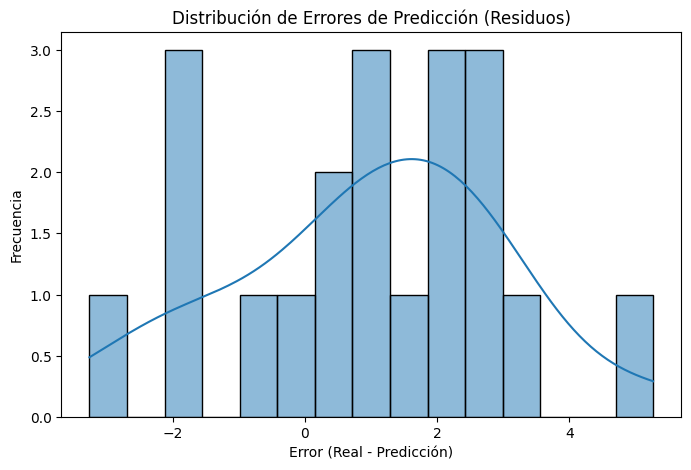

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(y_test - y_pred, bins=15, kde=True)
plt.title('Distribución de Errores de Predicción (Residuos)')
plt.xlabel('Error (Real - Predicción)')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
import ipywidgets as widgets

def evaluar_predicciones(threshold_mae):
    calidad = "buena" if mae <= threshold_mae else "regular o mala"
    print(f"Tu modelo tiene una MAE de {mae:.2f}, considerada {calidad} (umbral definido: {threshold_mae}).")

umbral_widget = widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1.0, description='Umbral MAE:')
widgets.interactive(evaluar_predicciones, threshold_mae=umbral_widget)

interactive(children=(FloatSlider(value=1.0, description='Umbral MAE:', max=5.0, min=0.1), Output()), _dom_cla…

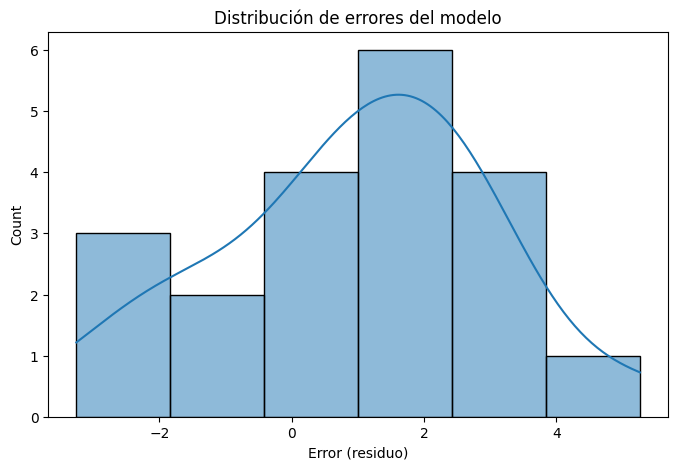

In [ ]:
residuos = y_test - y_pred
plt.figure(figsize=(8,5))
sns.histplot(residuos, kde=True)
plt.xlabel("Error (residuo)")
plt.title("Distribución de errores del modelo")
plt.show()

In [ ]:

# Cargar modelo entrenado previamente
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Dataset
df = pd.read_csv("/data/partidos_cebollitas.csv")
df['diferencia_goles'] = df['goles_local'] - df['goles_visitante']
X = df[['posesion_local (%)', 'tiros_arco_local']]
y = df['diferencia_goles']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo base
modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

In [ ]:

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

RMSE: 2.23
R²: -0.03


In [ ]:

if r2 < 0:
    print(" El modelo no explica la varianza. Peor que adivinar.")
elif r2 < 0.3:
    print(" El modelo explica muy poco. Posible underfitting.")
else:
    print(" El modelo tiene un poder explicativo aceptable.")

❌ El modelo no explica la varianza. Peor que adivinar.


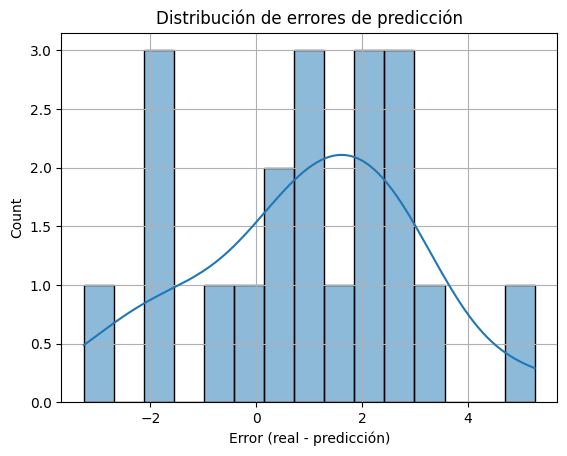

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(y_test - y_pred, bins=15, kde=True)
plt.title("Distribución de errores de predicción")
plt.xlabel("Error (real - predicción)")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Cargar el dataset
df = pd.read_csv("/data/partidos_cebollitas.csv")

In [ ]:

# Crear nuevas variables que ayudarán al modelo
df['diferencia_goles'] = df['goles_local'] - df['goles_visitante']
df['diferencia_posesion'] = df['posesion_local (%)'] - df['posesion_visitante (%)']
df['eficiencia_tiros_local'] = df['goles_local'] / (df['tiros_arco_local'] + 1e-5)
df['eficiencia_tiros_visitante'] = df['goles_visitante'] / (df['tiros_arco_visitante'] + 1e-5)
df['local_es_cebollitas'] = (df['equipo_local'] == 'Cebollitas FC').astype(int)
df = pd.get_dummies(df, columns=['estadio'], drop_first=True)

In [ ]:
# Elegimos las variables más informativas
features = [
    'posesion_local (%)', 'tiros_arco_local', 'diferencia_posesion',
    'eficiencia_tiros_local', 'eficiencia_tiros_visitante',
    'local_es_cebollitas'
] + [col for col in df.columns if col.startswith("estadio_")]

X = df[features]
y = df['diferencia_goles']

In [ ]:
# Separar en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:

# Entrenamos el modelo Random Forest
modelo_rf = RandomForestRegressor(n_estimators=1000, random_state=42)
modelo_rf.fit(X_train, y_train)

# Hacer predicciones
y_pred_rf = modelo_rf.predict(X_test)

In [ ]:

# Métricas de evaluación
from sklearn.metrics import mean_absolute_error


rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"📊 RMSE: {rmse_rf:.2f}")
print(f"📉 MAE: {mae_rf:.2f}")
print(f"📈 R²: {r2_rf:.2f}")

📊 RMSE: 0.90
📉 MAE: 0.67
📈 R²: 0.83


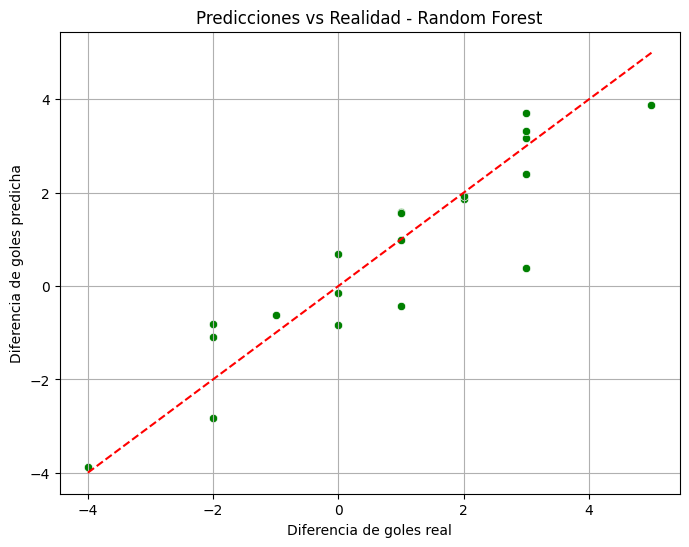

In [ ]:

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_rf, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Diferencia de goles real")
plt.ylabel("Diferencia de goles predicha")
plt.title("Predicciones vs Realidad - Random Forest")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Métricas obtenidas del modelo de regresión lineal
metricas_rl = {
    'Modelo': 'Regresión Lineal',
    'RMSE': 2.23,
    'MAE': 1.89,
    'R²': -0.03
}

# Métricas del Árbol de Decisión (bonus)
metricas_arbol = {
    'Modelo': 'Árbol de Decisión',
    'RMSE': 0.90,
    'MAE': 0.67,
    'R²': 0.83
}
# Comparación
df_comparacion = pd.DataFrame([metricas_rl, metricas_arbol])
display(df_comparacion)

,Modelo,RMSE,MAE,R²
0,Regresión Lineal,2.23,1.89,-0.03
1,Árbol de Decisión,0.90,0.67,0.83


In [ ]:
import pandas as pd
df_jugadores = pd.read_csv("/data/jugadores_cebollitas.csv")
df_jugadores.head()

,jugador_id,nombre,posición,edad,partidos_jugados,goles,asistencias,pases_completados (%),tiros_al_arco,precisión_tiros (%),minutos_jugados
0,1,Tara Alvarez,Portero,18,25,2,5,89.0,8,78.2,2125
1,2,Carol Mcclain,Mediocampista,32,12,2,8,77.5,49,68.5,1032
2,3,Robert Martin,Defensa,26,12,4,5,87.3,1,71.4,816
3,4,Mr. Robert Turner,Defensa,25,17,2,4,75.9,9,35.8,1496
4,5,Christopher Kennedy,Defensa,35,23,1,7,83.5,0,0.0,2047


## Modelado No Supervisado: Segmentación de Jugadores
Se aplicó un algoritmo de agrupamiento para segmentar a los jugadores según sus estadísticas individuales:

- El análisis permitió identificar tres perfiles distintos basados en goles, asistencias y precisión de pases.
- Se utilizaron gráficos de dispersión y diagramas de caja por clúster para validar que cada grupo representa un rol táctico diferente en el equipo.


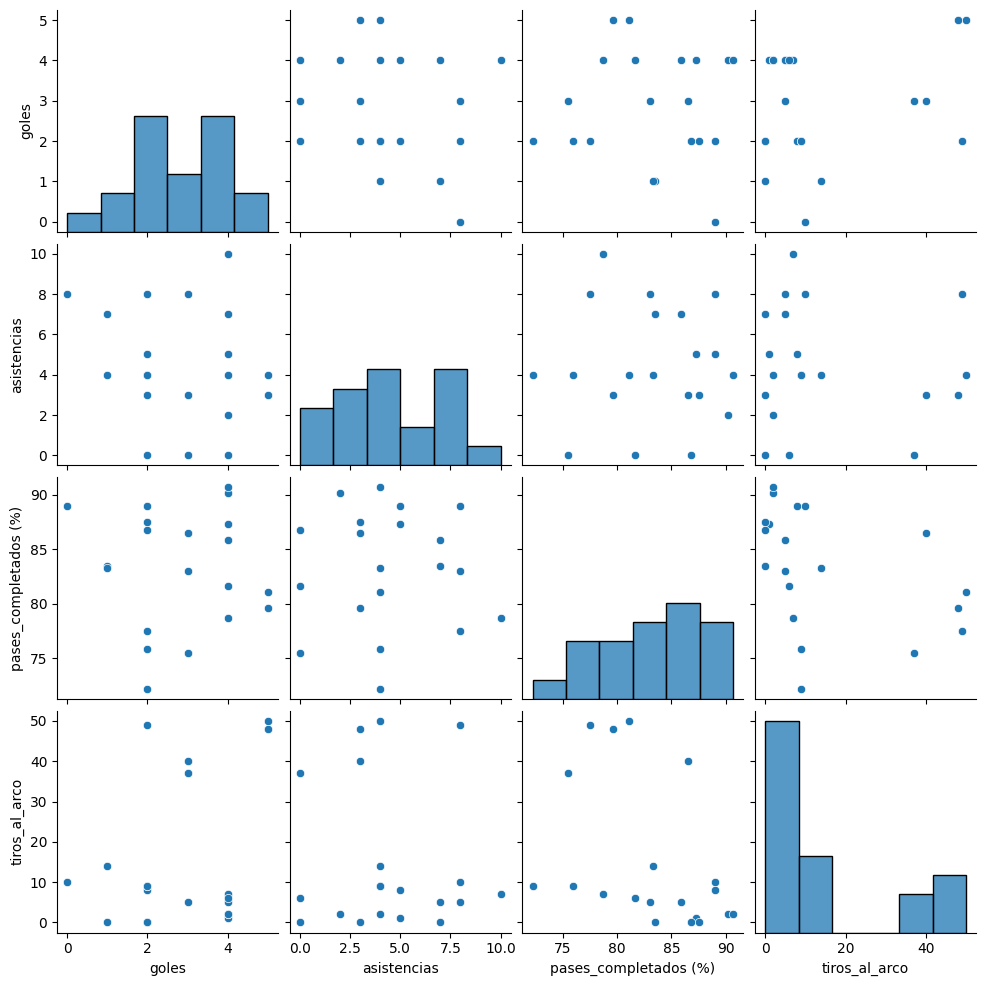

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_jugadores[['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']])
plt.show()

In [ ]:
from sklearn.cluster import KMeans

X = df_jugadores[['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']]

kmeans = KMeans(n_clusters=3, random_state=42)
df_jugadores['cluster'] = kmeans.fit_predict(X)

df_jugadores.head()

,jugador_id,nombre,posición,edad,partidos_jugados,goles,asistencias,pases_completados (%),tiros_al_arco,precisión_tiros (%),minutos_jugados,cluster
0,1,Tara Alvarez,Portero,18,25,2,5,89.0,8,78.2,2125,1
1,2,Carol Mcclain,Mediocampista,32,12,2,8,77.5,49,68.5,1032,0
2,3,Robert Martin,Defensa,26,12,4,5,87.3,1,71.4,816,1
3,4,Mr. Robert Turner,Defensa,25,17,2,4,75.9,9,35.8,1496,2
4,5,Christopher Kennedy,Defensa,35,23,1,7,83.5,0,0.0,2047,1


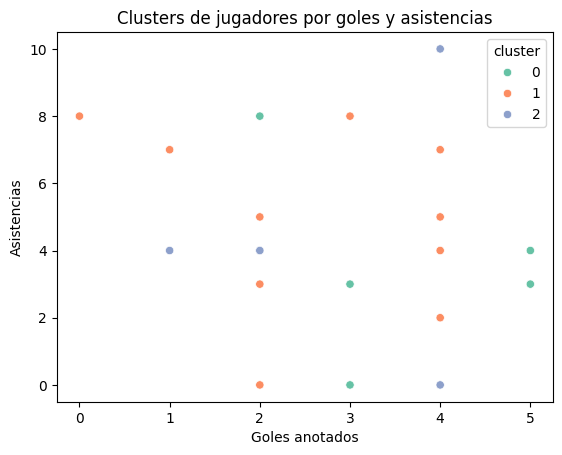

In [ ]:
sns.scatterplot(x='goles', y='asistencias', hue='cluster', palette='Set2', data=df_jugadores)
plt.title("Clusters de jugadores por goles y asistencias")
plt.xlabel("Goles anotados")
plt.ylabel("Asistencias")
plt.show()

In [ ]:
columnas_numericas = ['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']
perfiles = df_jugadores.groupby('cluster')[columnas_numericas].mean()
print(perfiles)

         goles  asistencias  pases_completados (%)  tiros_al_arco
cluster                                                          
0          3.6          3.6                  80.04           44.8
1          2.6          4.9                  87.29            3.3
2          2.6          4.4                  78.34            9.0


In [ ]:

import ipywidgets as widgets

def clustering_interactivo(k):
    km = KMeans(n_clusters=k, random_state=42)
    df_jugadores['cluster_temp'] = km.fit_predict(X)

    sns.scatterplot(x='goles', y='asistencias', hue='cluster_temp', palette='Set1', data=df_jugadores)
    plt.title(f"Clustering jugadores con {k} clusters")
    plt.xlabel("Goles")
    plt.ylabel("Asistencias")
    plt.show()

widgets.interactive(clustering_interactivo, k=(2,6,1))# quiere decir que el k va a ir del 2 al 6 avanzando de 1 en 1

interactive(children=(IntSlider(value=4, description='k', max=6, min=2), Output()), _dom_classes=('widget-inte…

(0≤uij≤10 \leq u_{ij} \leq 10≤uij​≤1) a cada clúster.

/tmp/ipython-input-3013497276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')


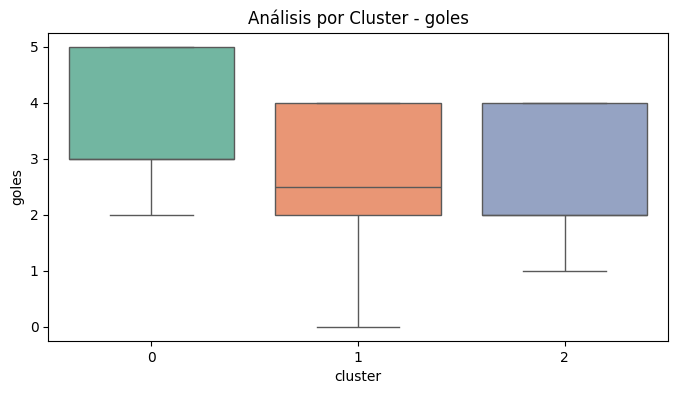

/tmp/ipython-input-3013497276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')


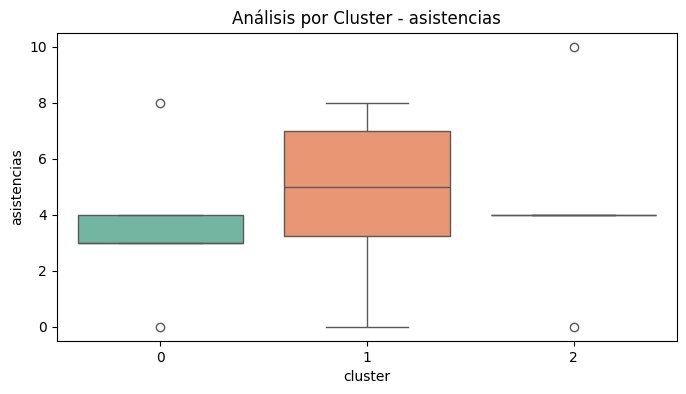

/tmp/ipython-input-3013497276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')


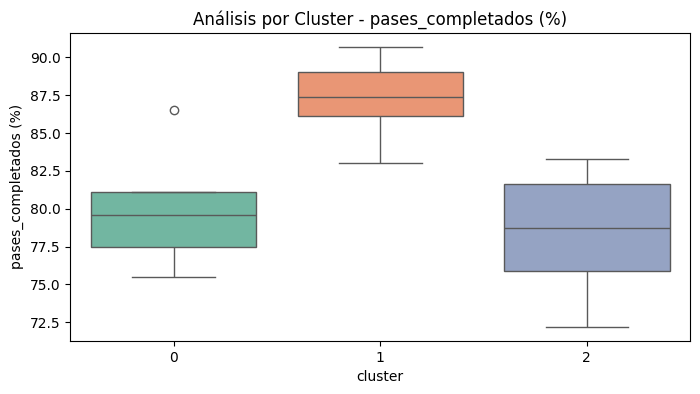

/tmp/ipython-input-3013497276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')


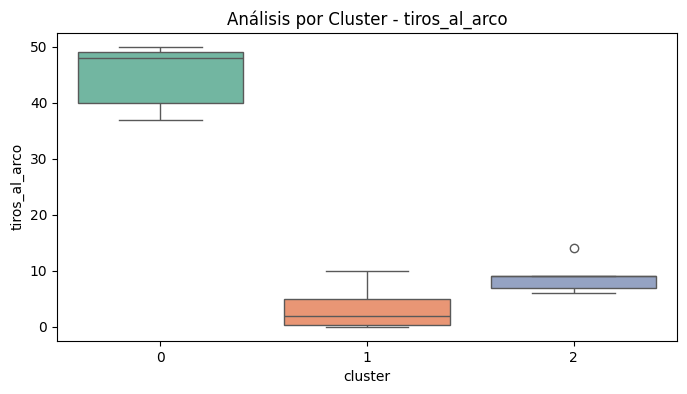

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


features = ['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']

for feature in features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')
    plt.title(f'Análisis por Cluster - {feature}')
    plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Dropdown interactivo
cluster_selector = widgets.Dropdown(
    options=sorted(df_jugadores['cluster'].unique()),
    description='Cluster:'
)

# Función de despliegue
def mostrar_jugadores(cluster):
    jugadores = df_jugadores[df_jugadores['cluster'] == cluster]
    display(jugadores[['nombre', 'goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']])

# Activar widget
widgets.interactive(mostrar_jugadores, cluster=cluster_selector)

#Muestra los jugadores que pertenece a cada cluster

interactive(children=(Dropdown(description='Cluster:', options=(np.int32(0), np.int32(1), np.int32(2)), value=…

## Reducción de Dimensionalidad (PCA)
Para visualizar la complejidad de los perfiles de los jugadores:

- Se utilizó el análisis de componentes principales (PCA).
- Se transformaron las métricas originales en dos componentes principales que facilitan la observación de la estructura de los datos.
- Los dos primeros componentes explican el 67.04% de la varianza total, permitiendo confirmar que la segmentación realizada por el algoritmo es matemáticamente sólida.


In [ ]:

# Manipulación de datos
import pandas as pd

df_jugadores = pd.read_csv("/data/jugadores_cebollitas.csv")
X = df_jugadores[['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']]

In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)

df_jugadores['PC1'] = componentes[:,0]# agarra todos los elementos que esten en la primera columna del arary
df_jugadores['PC2'] = componentes[:,1]# agarra todos los elementos que esten en la segunda columna del arary

df_jugadores.isnull().sum()

,0
jugador_id,0
nombre,0
posición,0
edad,0
partidos_jugados,0
goles,0
asistencias,0
pases_completados (%),0
tiros_al_arco,0
precisión_tiros (%),0


<Axes: xlabel='PC1', ylabel='PC2'>

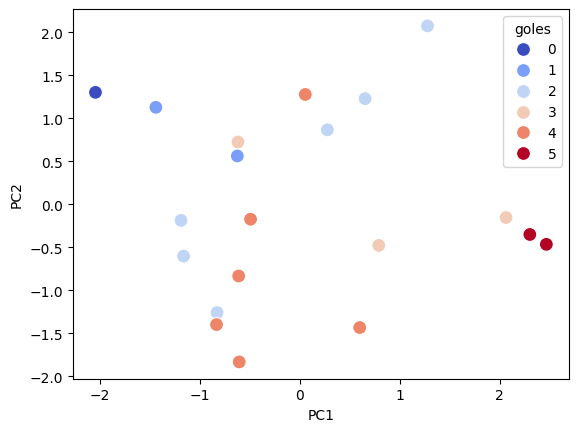

In [ ]:

import seaborn as sns

sns.scatterplot(x='PC1', y='PC2', data=df_jugadores,
                hue='goles', palette='coolwarm', s=100)

In [ ]:

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df_jugadores['cluster'] = kmeans.fit_predict(X_scaled)

<Axes: xlabel='PC1', ylabel='PC2'>

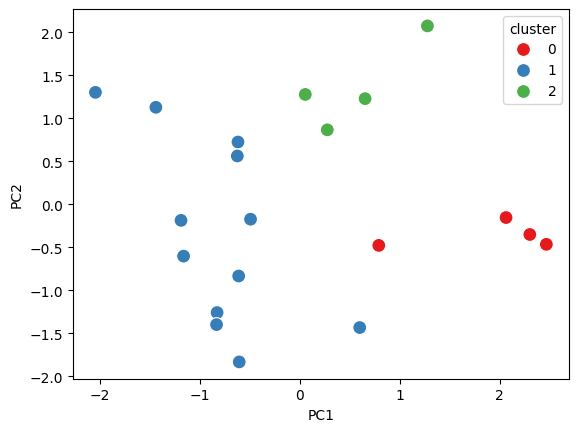

In [ ]:
sns.scatterplot(x='PC1', y='PC2', hue='cluster',
                palette='Set1', data=df_jugadores, s=100)


In [ ]:

varianza = pca.explained_variance_ratio_

print(f"Varianza explicada por PC1: {varianza[0]:.2%}")
print(f"Varianza explicada por PC2: {varianza[1]:.2%}")
print(f"Varianza total explicada: {varianza.sum():.2%}")

Varianza explicada por PC1: 38.65%
Varianza explicada por PC2: 28.39%
Varianza total explicada: 67.04%


In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt


def explorar_componentes(eje_x, eje_y):
    plt.figure(figsize=(10,6))
    sns.scatterplot(x=eje_x, y=eje_y, hue='cluster', data=df_jugadores, palette='Set2', s=100)
    plt.title(f'Clusters en espacio {eje_x} vs {eje_y}')
    plt.grid(True)
    plt.show()

widgets.interactive(
    explorar_componentes,
    eje_x=['PC1', 'PC2'],
    eje_y=['PC1', 'PC2']
)

interactive(children=(Dropdown(description='eje_x', options=('PC1', 'PC2'), value='PC1'), Dropdown(description…

## Implementaciones de Vanguardia: Deep Learning y NLP

El proyecto extiende su alcance hacia áreas más complejas de la inteligencia artificial.

- **Deep Learning con PyTorch**:  
  Se diseñó una red neuronal multicapa (**RedSimple**) con funciones de activación ReLU y Sigmoid. El modelo fue entrenado con el optimizador Adam, logrando una precisión inicial del 54.00% en tareas de clasificación.

- **Procesamiento de Lenguaje Natural (NLP)**:  
  Se procesaron 100 comentarios mediante expresiones regulares para la limpieza de texto. El análisis de sentimientos reveló una distribución donde el sentimiento neutral predomina, seguido de los comentarios negativos, lo que permite mapear la percepción de la afición ante los resultados.

## Optimización de Flujos con Pipelines

Para garantizar la escalabilidad y evitar la fuga de datos (data leakage), se implementaron Pipelines de Scikit-learn.  
Esto permite encapsular el escalado y el modelado (tanto supervisado como no supervisado) en un solo objeto, facilitando la transición a entornos de producción o el procesamiento de nuevos datos de partidos y jugadores.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.cluster import KMeans

# Dataset de partidos
df_partidos = pd.read_csv("/data/partidos_cebollitas.csv")
df_partidos['diferencia_goles'] = df_partidos['goles_local'] - df_partidos['goles_visitante']

X_partidos = df_partidos[['posesion_local (%)', 'tiros_arco_local']]
y_partidos = df_partidos['diferencia_goles']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_partidos, y_partidos, test_size=0.2, random_state=42)

# Dataset de jugadores
df_jugadores = pd.read_csv("/data/jugadores_cebollitas.csv")
X_jugadores = df_jugadores[['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']]

In [ ]:

pipeline_supervisado = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
pipeline_supervisado.fit(X_train_p, y_train_p)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())])

In [ ]:
pipeline_no_supervisado = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=3, random_state=42))
])
df_jugadores['cluster'] = pipeline_no_supervisado.fit_predict(X_jugadores)

In [ ]:

nuevo_partido = pd.DataFrame({'posesion_local (%)':[58],'tiros_arco_local':[9]})
prediccion_partido = pipeline_supervisado.predict(nuevo_partido)

perfiles_jugadores = df_jugadores[['nombre', 'cluster']].head(10)

print(f"Predicción resultado partido (dif. goles): {prediccion_partido.round(2)}")
print("\nPerfiles jugadores (primeros 10):")
print(perfiles_jugadores)

Predicción resultado partido (dif. goles): [0.25]

Perfiles jugadores (primeros 10):
                nombre  cluster
0         Tara Alvarez        1
1        Carol Mcclain        2
2        Robert Martin        1
3    Mr. Robert Turner        2
4  Christopher Kennedy        1
5  Dr. Justin Anderson        0
6      Sandra Shepherd        1
7          Mark Bowers        0
8         Kenneth Cook        1
9    Christopher Parks        2


In [ ]:

import ipywidgets as widgets

posesion_widget = widgets.IntSlider(min=40,max=70,description='Posesión %:')
tiros_widget = widgets.IntSlider(min=1,max=15,description='Tiros al arco:')

def predecir_resultados(posesion, tiros):
    datos = pd.DataFrame({'posesion_local (%)':[posesion],'tiros_arco_local':[tiros]})
    pred = pipeline_supervisado.predict(datos)[0]
    print(f"Diferencia de goles predicha: {pred:.2f}")

widgets.interactive(predecir_resultados, posesion=posesion_widget, tiros=tiros_widget)

interactive(children=(IntSlider(value=40, description='Posesión %:', max=70, min=40), IntSlider(value=1, descr…

In [ ]:
import torch                              # 1. PyTorch principal.
import torch.nn as nn                     # 2. Módulos de redes (capas, funciones de activación…).
import torch.optim as optim               # 3. Optimizadores (Adam, SGD…).
import numpy as np                        # 4. Para datos de ejemplo.


# 1. Creamos datos aleatorios con NumPy
X_np = np.random.rand(100, 4).astype(np.float32)   # 100×4 entradas, float32 para PyTorch
y_np = np.random.randint(0, 2, size=(100,)).astype(np.int64)  # 100 etiquetas binarias

# 2. Convertimos a tensores de PyTorch
X = torch.from_numpy(X_np)     # Tensor de tamaño [100, 4]
y = torch.from_numpy(y_np)     # Tensor de tamaño [100]

In [ ]:

class RedSimple(nn.Module):
    def __init__(self, n_entradas, n_ocultas, n_salidas):
        super().__init__()
        # 1. Capa oculta
        self.hidden = nn.Linear(n_entradas, n_ocultas)
        # 2. Capa de salida
        self.output = nn.Linear(n_ocultas, n_salidas)
        # 3. Función de activación ReLU
        self.relu = nn.ReLU()
        # 4. Sigmoide para la salida binaria
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # 5. Paso hacia adelante: entrada → oculta → activación → salida → sigmoide
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.sigmoid(x).squeeze(1)
        return x

# 6. Creamos una instancia: 4 entradas → 8 neuronas ocultas → 1 salida
modelo = RedSimple(n_entradas=4, n_ocultas=8, n_salidas=1)



In [ ]:

# 1. Loss: entropía cruzada binaria para entradas de probabilidad
criterion = nn.BCELoss()

# 2. Optimizador Adam con tasa de aprendizaje por defecto
optimizer = optim.Adam(modelo.parameters(), lr=0.001)

In [ ]:
n_epochs = 10
batch_size = 10
dataset = torch.utils.data.TensorDataset(X, y)
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

for epoch in range(n_epochs):
    for X_batch, y_batch in loader:
        # 1. Forward
        y_pred = modelo(X_batch)
        # 2. Calcular pérdida
        loss = criterion(y_pred, y_batch.float())
        # 3. Backprop y optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # 4. Mostrar progreso por época
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

Epoch 1/10, Loss: 0.6211
Epoch 2/10, Loss: 0.7067
Epoch 3/10, Loss: 0.6373
Epoch 4/10, Loss: 0.6973
Epoch 5/10, Loss: 0.6252
Epoch 6/10, Loss: 0.6548
Epoch 7/10, Loss: 0.7119
Epoch 8/10, Loss: 0.7238
Epoch 9/10, Loss: 0.6291
Epoch 10/10, Loss: 0.5965


In [ ]:
with torch.no_grad():
    y_prob = modelo(X)             # 1. Predicciones de probabilidad
    y_pred = (y_prob > 0.5).int()  # 2. Convertir a 0/1 con umbral 0.5
    accuracy = (y_pred == y).float().mean()  # 3. Proporción de aciertos
    print(f"Precisión del modelo: {accuracy*100:.2f}%")

Precisión del modelo: 54.00%


In [ ]:

print(modelo)
# Muestra las capas en orden y sus tamaños

RedSimple(
  (hidden): Linear(in_features=4, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


In [ ]:
import ipywidgets as widgets

capas_widget = widgets.IntSlider(min=1, max=5, description='Capas Ocultas:')

def probar_pytorch(cap):
    # 1. Creamos secuencia de capas según slider
    class RedDyn(nn.Module):
        def __init__(self, n_entradas, n_ocultas, n_capas):
            super().__init__()
            self.layers = nn.ModuleList()
            self.layers.append(nn.Linear(n_entradas, n_ocultas))
            for _ in range(n_capas-1):
                self.layers.append(nn.Linear(n_ocultas, n_ocultas))
            self.out = nn.Linear(n_ocultas, 1)
            self.relu = nn.ReLU()
            self.sig = nn.Sigmoid()
        def forward(self, x):
            for layer in self.layers:
                x = self.relu(layer(x))
            x = self.sig(self.out(x)).squeeze(1)
            return x

    model = RedDyn(4, 4, cap)  # 4 características, 4 neuronas por capa
    crit = nn.BCELoss()
    opt = optim.Adam(model.parameters(), lr=0.001)

    # Entrenamiento rápido (3 épocas)
    for _ in range(3):
        y_p = model(X)
        l = crit(y_p, y.float())
        opt.zero_grad(); l.backward(); opt.step()

    # Evaluación
    with torch.no_grad():
        y_p = model(X)
        preds = (y_p>0.5).int()
        acc = (preds==y).float().mean()
    print(f"Precisión con {cap} capas: {acc*100:.2f}%")

widgets.interactive(probar_pytorch, cap=capas_widget)

interactive(children=(IntSlider(value=1, description='Capas Ocultas:', max=5, min=1), Output()), _dom_classes=…

In [ ]:

import pandas as pd

# Cargar dataset
df = pd.read_csv("/data/comentarios_deportivos.csv")

# Asegurar que los comentarios sean texto
df['comentario'] = df['comentario'].astype(str)

# Vista rápida
df.head()

,id,comentario,sentimiento
0,180,"Partido equilibrado, resultado justo.",Neutral
1,177,"Encuentro equilibrado, reparto justo de puntos.",Neutral
2,189,Resultado esperado dadas las circunstancias.,Neutral
3,132,Nuestro ataque no generó peligro suficiente.,Negativo
4,148,"Sin sobresaltos, rendimiento promedio.",Neutral


In [ ]:

import re

# Función simple y efectiva para limpiar texto
def limpiar_texto_simple(texto):
    texto = texto.lower()
    texto = re.sub(r"[^a-záéíóúñü\s]", "", texto)  # Solo letras y espacios
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

# Aplicar limpieza
df['comentario_limpio'] = df['comentario'].apply(limpiar_texto_simple)

# Revisar ejemplos
df[['comentario', 'comentario_limpio']].sample(10)

,comentario,comentario_limpio
42,Nuestro portero estuvo sobresaliente.,nuestro portero estuvo sobresaliente
21,Rendimiento estable en defensa y ataque.,rendimiento estable en defensa y ataque
100,Nuestro ataque no generó peligro suficiente.,nuestro ataque no generó peligro suficiente
74,La defensa estuvo impecable hoy.,la defensa estuvo impecable hoy
2,Resultado esperado dadas las circunstancias.,resultado esperado dadas las circunstancias
137,Jugamos acorde a nuestro nivel habitual.,jugamos acorde a nuestro nivel habitual
115,"Perdimos merecidamente, mal rendimiento general.",perdimos merecidamente mal rendimiento general
199,"Mala estrategia, el técnico cometió errores.",mala estrategia el técnico cometió errores
174,Errores constantes en pases y posesión.,errores constantes en pases y posesión
75,Ambos equipos tuvieron oportunidades.,ambos equipos tuvieron oportunidades


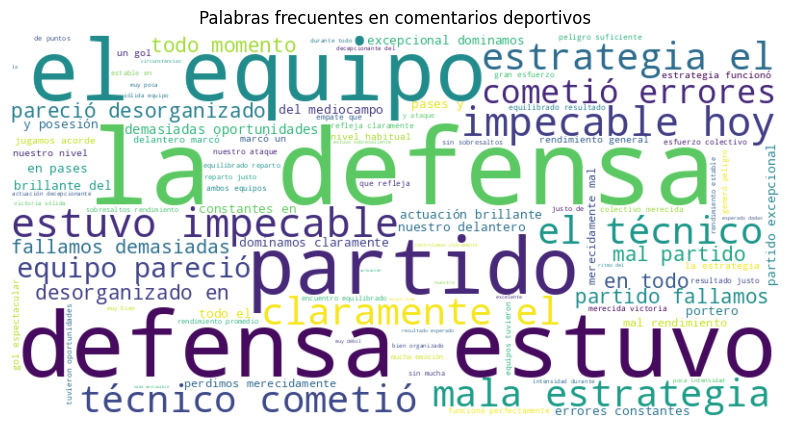

In [ ]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filtrar comentarios útiles
df_filtrado = df[df['comentario_limpio'].str.strip().astype(bool)]

# Unir todos los comentarios limpios
texto_total = ' '.join(df_filtrado['comentario_limpio'])

# Generar nube
if texto_total:
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texto_total)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Palabras frecuentes en comentarios deportivos")
    plt.show()
else:
    print(" No hay palabras útiles después del preprocesamiento.")

/tmp/ipython-input-1655371000.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentimiento', data=df, palette='viridis')


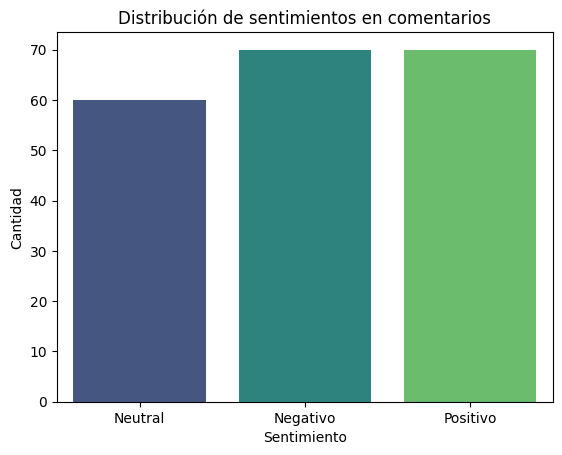

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

# Verificar columna
if 'sentimiento' in df.columns:
    sns.countplot(x='sentimiento', data=df, palette='viridis')
    plt.title('Distribución de sentimientos en comentarios')
    plt.xlabel('Sentimiento')
    plt.ylabel('Cantidad')
    plt.show()
else:
    print(" No se encontró la columna 'sentimiento'.")

In [ ]:

import ipywidgets as widgets
from IPython.display import display

sentimiento_widget = widgets.Dropdown(options=df['sentimiento'].unique(), description='Sentimiento:')

def mostrar_comentarios(sentimiento):
    seleccionados = df[df['sentimiento'] == sentimiento]
    display(seleccionados[['comentario', 'comentario_limpio']].sample(5))

widgets.interactive(mostrar_comentarios, sentimiento=sentimiento_widget)

interactive(children=(Dropdown(description='Sentimiento:', options=('Neutral', 'Negativo', 'Positivo'), value=…

## Conclusión
Este análisis demuestra que el uso de herramientas avanzadas permite transformar datos operativos en conocimiento estratégico. La transición de modelos simples a algoritmos de ensamble y técnicas de segmentación proporciona una capacidad de diagnóstico mucho más profunda sobre lo que ocurre en el campo de juego.  
Siguiente paso: integrar estas métricas en tiempo real para optimizar la toma de decisiones tácticas.






